# Case Study 1
Isaac Adoboe - ieadoboe@mun.ca
Student ID: 202384695

This case study explores explicit time-stepping schemes on the Lorenz ‘63
system and asks you to build and validate a reusable numerical solver. The main objective is to develop a
numerical model.

* Develop a numerical model of a chaotic system and verify convergence.
* Explore some properties of Lorenz system.
* Demonstrate the outcome of scientific inquiries about numerical solution of differential equations.

Consider the Lorenz System:

$$\frac{dx}{dt} = \sigma(y-x), \frac{dy}{dt} = x(\rho-z)-y, \frac{dx}{dt} = xy - \beta z$$


The parameters are $(\sigma, \rho, \beta)$ = (10, 28, 8/3)

In [11]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

### Lorenz System 

In [12]:
# Lorenz System 
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    """
    Args:
        t: time
        state: [x, y, z] current state
        sigma, rho, beta: Lorenz parameters
        
    Returns: 
        [dx/dt, dy/dt, dz/dt]
    """
    
    x, y, z = state
    
    dx_dt = sigma*(y - x)
    dy_dt = x*(rho - z)
    dz_dt = x*y - beta*z
    
    return np.array([dx_dt, dy_dt, dz_dt])

### Forward Euler method

$$y_{n+1} = y_n + dt * f(t_n, y_n)$$

In [13]:
# Forward Euler method
def euler(f, y0, t_span, dt):
    """
    Args:
        f: function that dy/dt given (t, y)
        y0: initial condition [array]
        t_span: (t_start, t_end)
        dt: time step
        
    Returns: 
        t: time points (array)
        y: solution values (array)
    """
    
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)
    n_steps = len(t)
    
    # solution array
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    # Time stepping
    for i in range(n_steps - 1):
        y[i+1] = y[i] + dt * f(t[i], y[i])
        
    return t, y
    

### Runge-Kutta method


In [14]:
# Runge-Kutta method
def rk4(f, y0, t_span, dt):
    """
        Args:
        f: function that dy/dt given (t, y)
        y0: initial condition [array]
        t_span: (t_start, t_end)
        dt: time step
        
    Returns: 
        t: time points (array)
        y: solution values (array)
    """
    
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)
    n_steps = len(t)
    
    # solution array
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    # Time stepping with RK4
    for i in range(n_steps - 1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + 0.5*dt, y[i] + 0.5*dt*k1)
        k3 = f(t[i] + 0.5*dt, y[i] + 0.5*dt*k2)
        k4 = f(t[i] + dt, y[i] + dt*k3)
        
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) * (dt/6)
        
    return t, y

### Solving Lorenz system

In [15]:
y0 = np.array([1., 2., 3.]) # Initial condition

t_span = (0, 100) # domain length
dt = 0.002 # time step size

In [16]:
t_euler, y_euler = euler(lorenz, y0, t_span, dt)
t_rk4, y_rk4 = rk4(lorenz, y0, t_span, dt)

print(f"Euler: {len(t_euler)} time steps")
print(f"RK4:   {len(t_rk4)} time steps")



Euler: 50001 time steps
RK4:   50001 time steps


In [17]:
y_euler

array([[ 1.        ,  2.        ,  3.        ],
       [ 1.02      ,  2.05      ,  2.988     ],
       [ 1.0406    ,  2.10102448,  2.976246  ],
       ...,
       [ 6.62019037,  3.02632517, 29.83317933],
       [ 6.54831307,  3.00205318, 29.71413873],
       [ 6.47738787,  2.97960374, 29.59498009]], shape=(50001, 3))

In [18]:
y_rk4

array([[ 1.        ,  2.        ,  3.        ],
       [ 1.02030143,  2.0505171 ,  2.98812321],
       [ 1.0412116 ,  2.10208892,  2.97649777],
       ...,
       [ 1.30201334, -0.50022672, 22.95159115],
       [ 1.26645704, -0.48710303, 22.82824396],
       [ 1.23186418, -0.47403054, 22.70562005]], shape=(50001, 3))

### Compare Lorenz trajectory as a 3D plot - Euler vs RK4

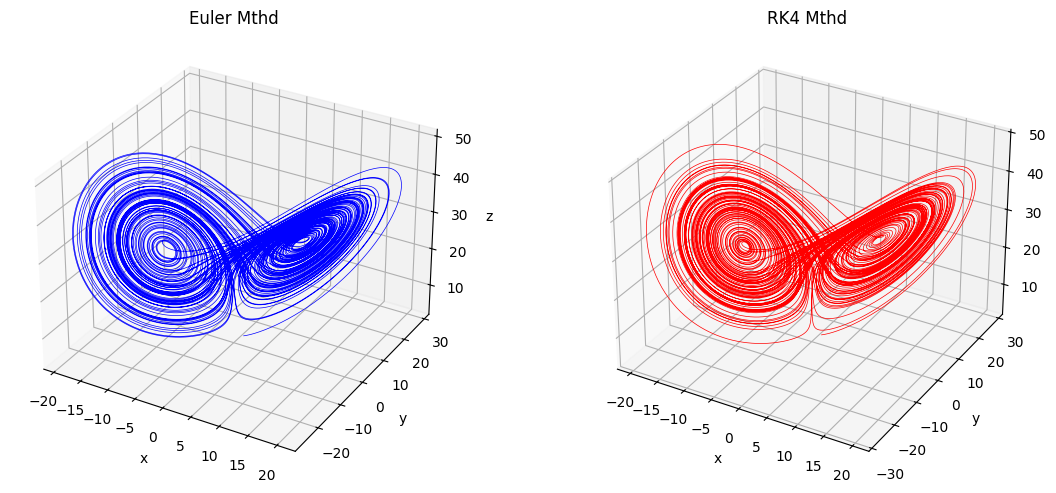

In [19]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot(y_euler[:, 0], y_euler[:, 1], y_euler[:, 2], "b-", linewidth=0.5)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("Euler Mthd")

ax1 = fig.add_subplot(122, projection="3d")
ax1.plot(y_rk4[:, 0], y_rk4[:, 1], y_rk4[:, 2], "r-", linewidth=0.5)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("RK4 Mthd")

plt.tight_layout()
plt.show()


Euler on top of RK4 (on the same plot)

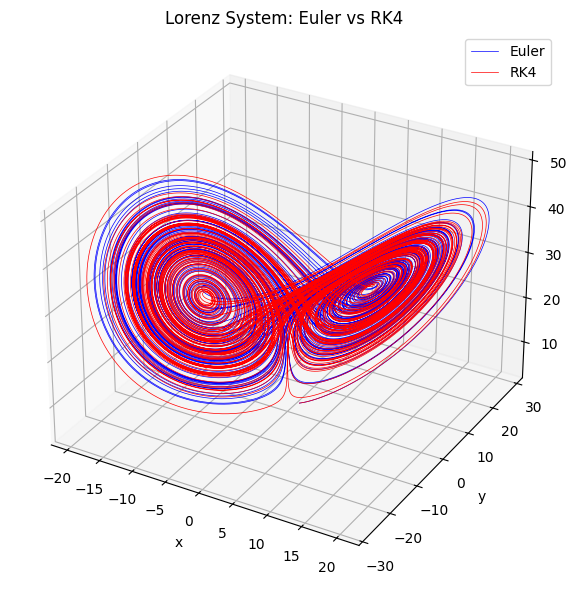

In [20]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(y_euler[:, 0], y_euler[:, 1], y_euler[:, 2], "b-", linewidth=0.5, label="Euler")
ax.plot(y_rk4[:, 0], y_rk4[:, 1], y_rk4[:, 2], "r-", linewidth=0.5, label="RK4")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz System: Euler vs RK4")
ax.legend()

plt.tight_layout()
plt.show()

The plot shows for the given initial conditions and time step, the two methods are very identical trajectories to each other. But RK4, moves quickly into the inner spiral than Euler method.

### Understanding Convergence: Using Leading Error Term

Briefly discuss what you observed regarding convergence as ∆t →0. Using lead error of any of the
method, explain the convergence behaviour that you observed.

The "leading error term" is the dominant term in the error expansion. It determines the convergence rate.

In Theory,

The global error in numerical methods is determined by accumulating local errors over $N = T/\Delta t$ steps. 
* For the Euler method, the local error has leading term $O(\Delta t^2)$, which accumulates to give global error with leading term $C·\Delta t$.
* For RK4, the local leading term is $O(\Delta t^5)$, accumulating to $K·\Delta t^4$ globally.

For the convergence analysis, we use the same time interval of 0 to 100 and initial conditions of `[1, 1, 1]`.

And test at time steps of
* 0.02
* 0.01
* 0.005
* 0.0025

In [21]:
y0 = np.array([1.0, 1.0, 1.0])
dt_values = [ 0.02, 0.01, 0.005, 0.0025, 0.00125]

### Euler Method: Leading Error Term Analysis


#### Euler Domain length => 0 to 100

In [22]:
t_end = 100.0


print(f"\n{'Time step':<12} {'Steps':<10} {'Global Error':<18} {'Ratio':<12}")
print("-"*50)

solutions_euler = {}
errors_euler = []

for dt in dt_values:
    t, y = euler(lorenz, y0, (0, t_end), dt)
    solutions_euler[dt] = (t, y)

for i in range(len(dt_values) - 1):
    dt_coarse = dt_values[i]
    dt_fine = dt_values[i + 1]
    
    _, y_coarse = solutions_euler[dt_coarse]
    _, y_fine = solutions_euler[dt_fine]
    
    error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
    errors_euler.append(error)
    
    if i > 0:
        ratio = errors_euler[i-1] / errors_euler[i]
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {ratio:<12.2f}")
    else:
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {'---':<12}")

avg_ratio_euler = np.mean([errors_euler[i]/errors_euler[i+1] 
                            for i in range(len(errors_euler)-1)])

print(f"\nObserved average ratio = {avg_ratio_euler:.2f}")
print(f"Theoritical leading error term = 2.0")


Time step    Steps      Global Error       Ratio       
--------------------------------------------------
0.02000      5001       17.917581          ---         
0.01000      10001      24.668354          0.73        
0.00500      20001      6.022758           4.10        
0.00250      40001      6.971733           0.86        

Observed average ratio = 1.90
Theoritical leading error term = 2.0


For the long integration time $(t \in [0, 100])$, the observed convergence ratio (~1.9) is close to the theoretical first-order behavior (ratio ≈ 2).
However, the ratios fluctuate strongly between step sizes, showing that accumulated numerical instability and chaotic divergence affect the apparent convergence. In the Lorenz system, errors grow exponentially with time, so small perturbations quickly dominate, masking the clean $O(h)$ convergence trend that Euler exhibits on shorter, more stable intervals.

In short, the results are consistent with first-order convergence, but the chaotic growth of errors in the Lorenz system limits the ability to observe it clearly over long time spans.

#### Euler Domain length => 0 to 2

In [23]:
t_end = 2.0


print(f"\n{'Time step':<12} {'Steps':<10} {'Global Error':<18} {'Ratio':<12}")
print("-"*50)

solutions_euler = {}
errors_euler = []

for dt in dt_values:
    t, y = euler(lorenz, y0, (0, t_end), dt)
    solutions_euler[dt] = (t, y)

for i in range(len(dt_values) - 1):
    dt_coarse = dt_values[i]
    dt_fine = dt_values[i + 1]
    
    _, y_coarse = solutions_euler[dt_coarse]
    _, y_fine = solutions_euler[dt_fine]
    
    error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
    errors_euler.append(error)
    
    if i > 0:
        ratio = errors_euler[i-1] / errors_euler[i]
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {ratio:<12.2f}")
    else:
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {'---':<12}")

avg_ratio_euler = np.mean([errors_euler[i]/errors_euler[i+1] 
                            for i in range(len(errors_euler)-1)])

print(f"\nObserved average ratio = {avg_ratio_euler:.2f}")
print(f"Theoritical leading error term = 2.0")


Time step    Steps      Global Error       Ratio       
--------------------------------------------------
0.02000      101        16.459834          ---         
0.01000      201        30.529758          0.54        
0.00500      401        23.577511          1.29        
0.00250      801        2.774830           8.50        

Observed average ratio = 3.44
Theoritical leading error term = 2.0


On the short interval $(t \in [0, 2])$, the system remains near its initial trajectory, and the chaotic divergence has not yet amplified small differences.
The ratios vary more erratically, but the average ratio of 3.44 still indicates a roughly first-order trend (within the noise of small sample size).
The large jump (ratio = 8.5) at the finest step likely reflects numerical sensitivity rather than a genuine higher-order accuracy.

####  In Summary:

For short domains, error dominates, but step-to-step variation can distort the apparent ratio.
For long domains, the Lorenz system’s sensitive dependence on initial conditions causes rapid error amplification, making the global error more reflective of system instability than the numerical method’s true convergence order.

Thus, Euler’s theoretical first-order convergence is only clearly observed in the short, non-chaotic regime; over long times, the chaotic nature of the Lorenz attractor overwhelms that theoretical behavior.

### Runge Kutta Method: Leading Error Term Analysis


#### RK4 Domain length => 0 to 100

In [24]:
t_end =100.0

print(f"\n{'Time step':<12} {'Steps':<10} {'Global Error':<18} {'Ratio':<12}")
print("-"*50)

solutions_rk4 = {}
errors_rk4 = []

for dt in dt_values:
    t, y = rk4(lorenz, y0, (0, t_end), dt)
    solutions_rk4[dt] = (t, y)

for i in range(len(dt_values) - 1):
    dt_coarse = dt_values[i]
    dt_fine = dt_values[i + 1]
    
    _, y_coarse = solutions_rk4[dt_coarse]
    _, y_fine = solutions_rk4[dt_fine]
    
    error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
    errors_rk4.append(error)
    
    if i > 0:
        ratio = errors_rk4[i-1] / errors_rk4[i]
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {ratio:<12.2f}")
    else:
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {'---':<12}")

avg_ratio_rk4 = np.mean([errors_rk4[i]/errors_rk4[i+1]
                        for i in range(len(errors_rk4)-1)])

print(f"\nObserved average ratio: {avg_ratio_rk4:.2f}")
print(f"Predicted by leading error term: 16.0")


Time step    Steps      Global Error       Ratio       
--------------------------------------------------
0.02000      5001       11.035027          ---         
0.01000      10001      7.307054           1.51        
0.00500      20001      20.072121          0.36        
0.00250      40001      25.821116          0.78        

Observed average ratio: 0.88
Predicted by leading error term: 16.0


Over the long interval the measured “global error at t=100” does not decrease with refinement in the way the fourth-order theory predicts. Errors are not consistent with $\Delta t$ (they go down for one refinement then jump up), and the observed average ratio (~0.88) is far from the expected 16. This indicates the measured  error is dominated by effects other than the leading term for RK4.

#### RK4 Domain length => 0 to 2

In [25]:
y0 = np.array([1.0, 1.0, 1.0])
t_end = 2.0
dt_values = [ 0.02, 0.01, 0.005, 0.0025, 0.00125]

print(f"\n{'Time step':<12} {'Steps':<10} {'Global Error':<18} {'Ratio':<12}")
print("-"*50)

solutions_rk4 = {}
errors_rk4 = []

for dt in dt_values:
    t, y = rk4(lorenz, y0, (0, t_end), dt)
    solutions_rk4[dt] = (t, y)

for i in range(len(dt_values) - 1):
    dt_coarse = dt_values[i]
    dt_fine = dt_values[i + 1]
    
    _, y_coarse = solutions_rk4[dt_coarse]
    _, y_fine = solutions_rk4[dt_fine]
    
    error = np.linalg.norm(y_coarse[-1] - y_fine[-1])
    errors_rk4.append(error)
    
    if i > 0:
        ratio = errors_rk4[i-1] / errors_rk4[i]
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {ratio:<12.2f}")
    else:
        print(f"{dt_coarse:<12.5f} {len(y_coarse):<10} {error:<18.6f} {'---':<12}")

avg_ratio_rk4 = np.mean([errors_rk4[i]/errors_rk4[i+1] 
                        for i in range(len(errors_rk4)-1)])

print(f"\nObserved average ratio: {avg_ratio_rk4:.2f}")
print(f"Predicted by leading error term: 16.0")


Time step    Steps      Global Error       Ratio       
--------------------------------------------------
0.02000      101        0.011709           ---         
0.01000      201        0.000458           25.57       
0.00500      401        0.000020           22.86       
0.00250      801        0.042278           0.00        

Observed average ratio: 16.14
Predicted by leading error term: 16.0


On the short interval the results match theory extremely well: halving ∆t produces error reductions consistent with $O(h^4)$. The two middle refinements show very close to the predicted factor ≈16, and the reported average (≈16.14) confirms fourth-order convergence in the asymptotic regime.

We observe an anomaly at the finest step (0.0025) produced a much larger error (0.042278) than the previous two refinements — an outlier that ruins the monotonic trend at the smallest h.

### Q3. 
Compare the solutions obtained by two methods. Plot t vs x(t), t vs y(t), and t vs z(t). For each plot,
you will show and compare two curves due to two methods. The time step and initial condition are your
choice, but the submission should state the value of $\Delta t$.

For these plots, I reduce the time span (or time range) to `0 to 10` so we can observe the difference between the two methods. I used an initial condition of `1, 1, 1` and a **time step ($\Delta t$ of 0.01)

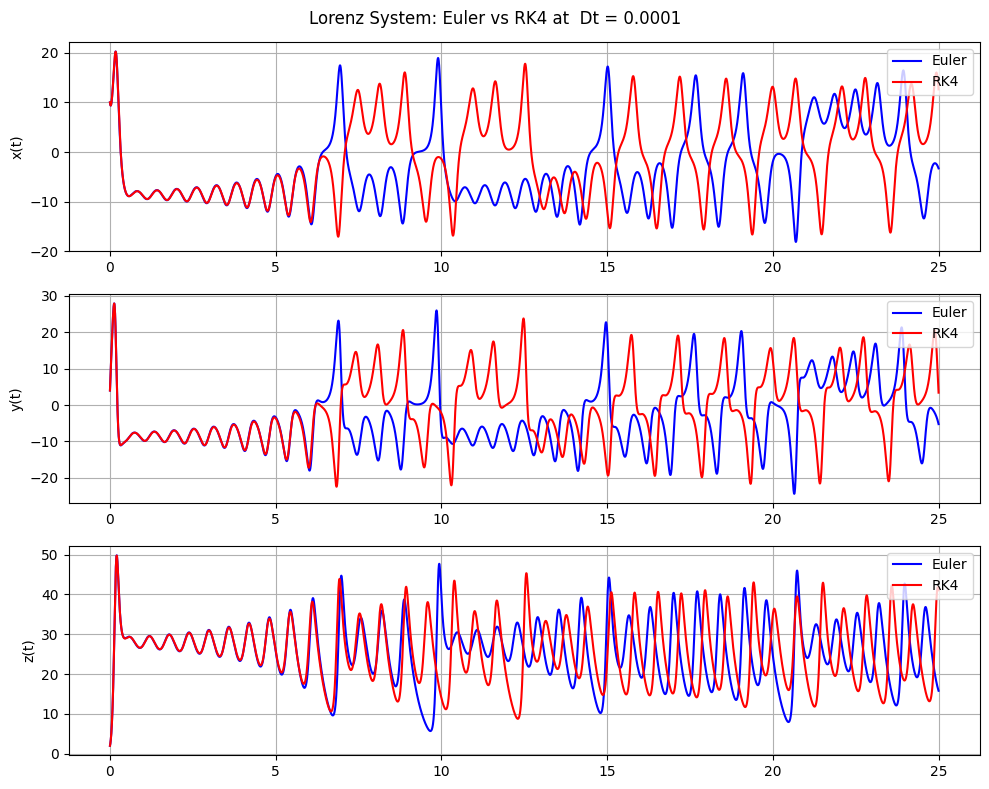

In [26]:
y0 = np.array([10., 4., 2.]) # Initial condition
t_span = (0, 25)
dt = 0.0001 # time step

t_euler, y_euler = euler(lorenz, y0, t_span, dt)
t_rk4, y_rk4 = rk4(lorenz, y0, t_span, dt)

fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Lorenz System: Euler vs RK4 at  Dt = 0.0001')

axs[0].plot(t_euler, y_euler[:, 0], 'b-', label='Euler')
axs[0].plot(t_rk4, y_rk4[:, 0], 'r-', label='RK4')
axs[0].set_ylabel("x(t)")
axs[0].legend(loc='upper right')
axs[0].grid(1)

axs[1].plot(t_euler, y_euler[:, 1], 'b-', label='Euler')
axs[1].plot(t_rk4, y_rk4[:, 1], 'r-', label='RK4')
axs[1].set_ylabel("y(t)")
axs[1].legend(loc='upper right')
axs[1].grid(1)


axs[2].plot(t_euler, y_euler[:, 2], 'b-', label='Euler')
axs[2].plot(t_rk4, y_rk4[:, 2], 'r-', label='RK4')
axs[2].set_ylabel("z(t)")
axs[2].legend(loc='upper right')
axs[2].grid(1)


plt.tight_layout()
plt.show()

Initially (t < 6), both methods produce identical solutions/paths under the same initial conditions of [10., 4., 2.]. Beyond t ≈ 15, the trajectories become completely uncorrelated due to the system's chaotic nature. The two methods, seem to take two seperate paths.

### Q5.

For the initial condition, I used a added a slight offset of `0.0001` to the x coordinate.

In [27]:
# Initial conditions
p0 = np.array([1.0, 1.0, 1.0])
q0 = p0 + np.array([0, 0.00000001, 0])

t_span = (0, 100)
dt = 0.01

print(f"Initial conditions:")
print(f"p(0) = {p0}")
print(f"q(0) = {q0}")

Initial conditions:
p(0) = [1. 1. 1.]
q(0) = [1.         1.00000001 1.        ]


### $\ln{\delta(t)}$ for Euler

In [28]:
t_p_euler, p_euler = euler(lorenz, p0, t_span, dt)
t_q_euler, q_euler = euler(lorenz, q0, t_span, dt)

delta_euler = np.linalg.norm(p_euler - q_euler, axis=1)

ln_delta_euler = np.log(delta_euler)

### $\ln{\delta(t)}$ for RK4

In [29]:
t_p_rk4, p_rk4 = rk4(lorenz, p0, t_span, dt)
t_q_rk4, q_rk4 = rk4(lorenz, q0, t_span, dt)

delta_rk4 = np.linalg.norm(p_rk4 - q_rk4, axis=1)

ln_delta_rk4 = np.log(delta_rk4)


### Plot of Divergence - t against $\ln{\delta(t)}$ for Euler vs RK4

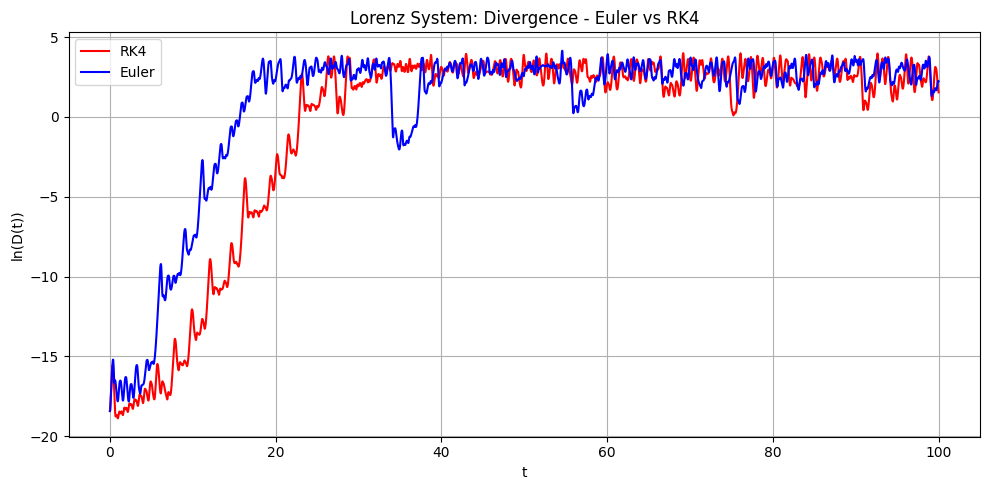

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(t_p_rk4, ln_delta_rk4, 'r-', label='RK4')
plt.plot(t_p_euler, ln_delta_euler, 'b-', label='Euler')
plt.xlabel("t")
plt.ylabel("ln(D(t))")
plt.title("Lorenz System: Divergence - Euler vs RK4")
plt.legend()
plt.grid(1)
plt.tight_layout()
plt.show()

### Estimate the value of $\alpha$

In [31]:
def estimate_lyapunov(t, log_delta, t_max_fit=10):
    # Only fit the exponential growth region (before saturation)
    mask = (t <= t_max_fit) & (log_delta > -50)  # Avoid -inf values
    
    if np.sum(mask) < 2:
        return np.nan, np.array([]), np.array([])
    
    t_fit = t[mask]
    log_delta_fit = log_delta[mask]
    
    # Linear least squares fit
    coeffs = np.polyfit(t_fit, log_delta_fit, 1)
    alpha = coeffs[0]  # Slope
    intercept = coeffs[1]
    
    # Generate fitted line
    log_delta_theory = alpha * t_fit + intercept
    
    return alpha, t_fit, log_delta_theory

In [32]:
alpha_euler, t_fit_euler, log_delta_fit_euler = estimate_lyapunov(t_p_euler, ln_delta_euler)
alpha_rk4, t_fit_rk4, log_delta_fit_rk4 = estimate_lyapunov(t_p_rk4, ln_delta_rk4)

print(f"Estimated alpha (Euler): {alpha_euler:.4f}")
print(f"Estimated alpha (RK4)  : {alpha_rk4:.4f}")

Estimated alpha (Euler): 1.1245
Estimated alpha (RK4)  : 0.3939
